In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, confusion_matrix

In [9]:
seeds_df = pd.read_csv('seeds_dataset.csv')
print(seeds_df.head(8))
print(seeds_df.info())
print(seeds_df.isnull().sum())
print(seeds_df.describe())

    area  perimeter  compactness  kernel_length  kernel_width  asymmetry  \
0  15.26      14.84       0.8710          5.763         3.312      2.221   
1  14.88      14.57       0.8811          5.554         3.333      1.018   
2  14.29      14.09       0.9050          5.291         3.337      2.699   
3  13.84      13.94       0.8955          5.324         3.379      2.259   
4  16.14      14.99       0.9034          5.658         3.562      1.355   
5  14.38      14.21       0.8951          5.386         3.312      2.462   
6  14.69      14.49       0.8799          5.563         3.259      3.586   
7  14.11      14.10       0.8911          5.420         3.302      2.700   

   groove_length  class  
0          5.220      1  
1          4.956      1  
2          4.825      1  
3          4.805      1  
4          5.175      1  
5          4.956      1  
6          5.219      1  
7          5.000      1  
<class 'pandas.DataFrame'>
RangeIndex: 210 entries, 0 to 209
Data columns (total 

In [12]:
dup_row = seeds_df[seeds_df.duplicated()]
print(f"Duplicate row Number: {dup_row.shape[0]}")
seeds_df.head(8)

Duplicate row Number: 0


,area,perimeter,compactness,kernel_length,kernel_width,asymmetry,groove_length,class
0,15.26,14.84,0.8710,5.763,3.312,2.221,5.220,1
1,14.88,14.57,0.8811,5.554,3.333,1.018,4.956,1
2,14.29,14.09,0.9050,5.291,3.337,2.699,4.825,1
3,13.84,13.94,0.8955,5.324,3.379,2.259,4.805,1
4,16.14,14.99,0.9034,5.658,3.562,1.355,5.175,1
5,14.38,14.21,0.8951,5.386,3.312,2.462,4.956,1
6,14.69,14.49,0.8799,5.563,3.259,3.586,5.219,1
7,14.11,14.10,0.8911,5.420,3.302,2.700,5.000,1


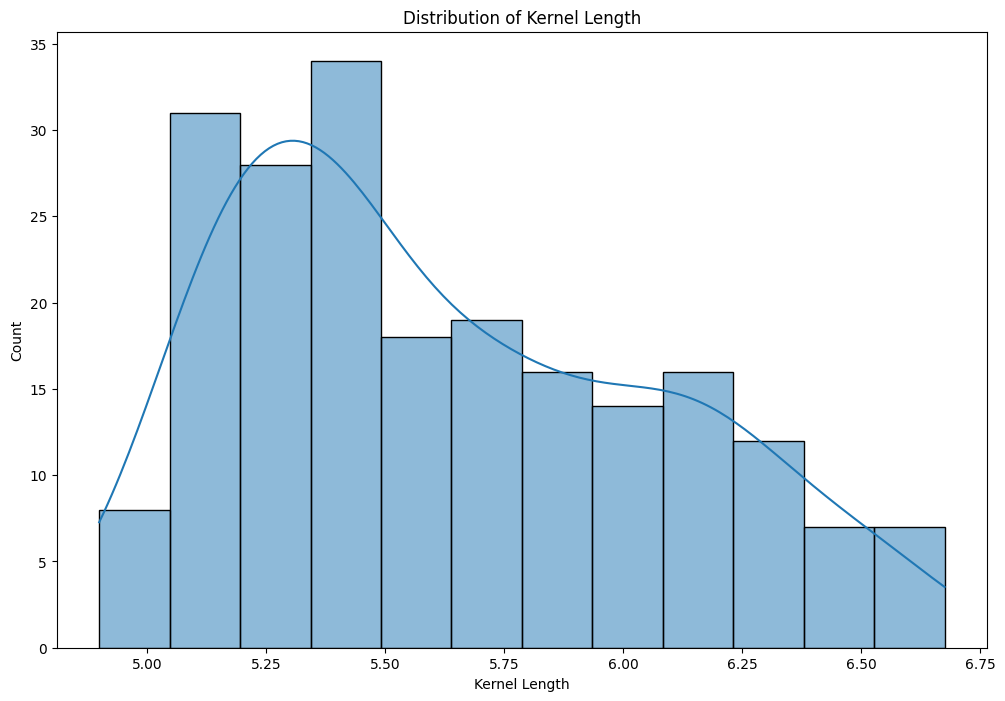

In [20]:
plt.figure(figsize=(12, 8))
sns.histplot(seeds_df['kernel_length'], bins=12, kde=True)
plt.title('Distribution of Kernel Length')
plt.xlabel('Kernel Length')
plt.ylabel('Count')
plt.show()

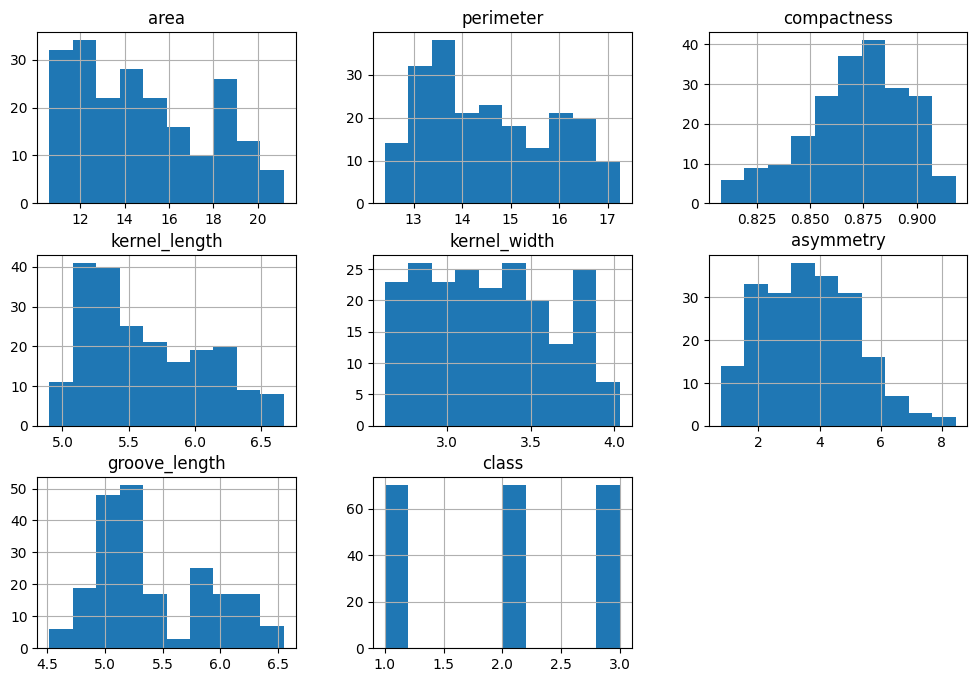

In [21]:
seeds_df.hist(figsize=(12,8))
plt.show()

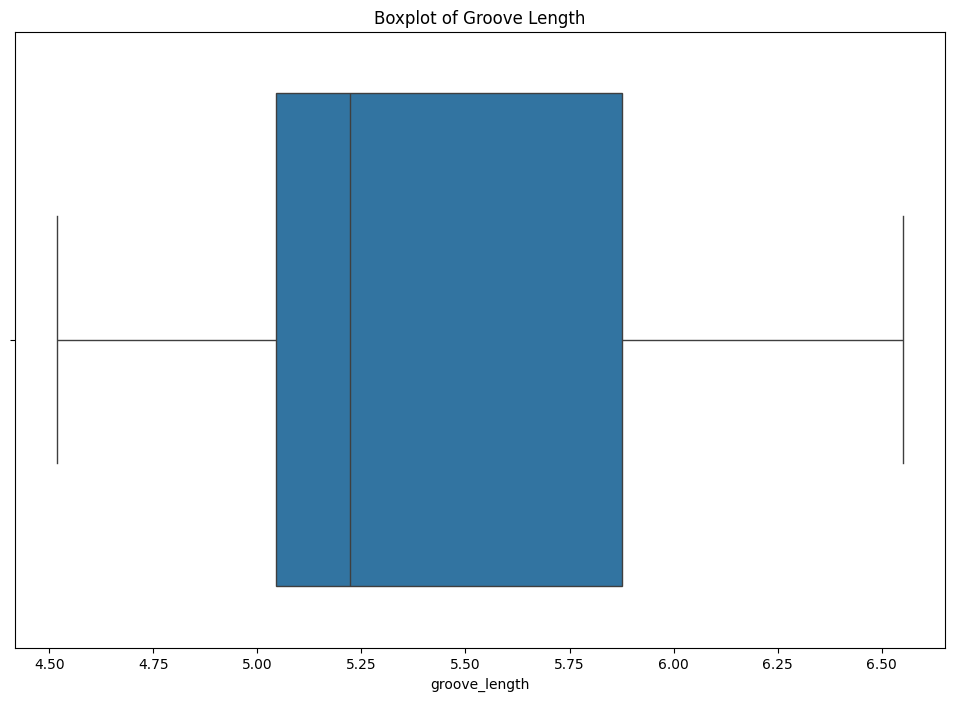

In [23]:
plt.figure(figsize=(12, 8))
sns.boxplot(x=seeds_df['groove_length'])
plt.title('Boxplot of Groove Length')
plt.show()

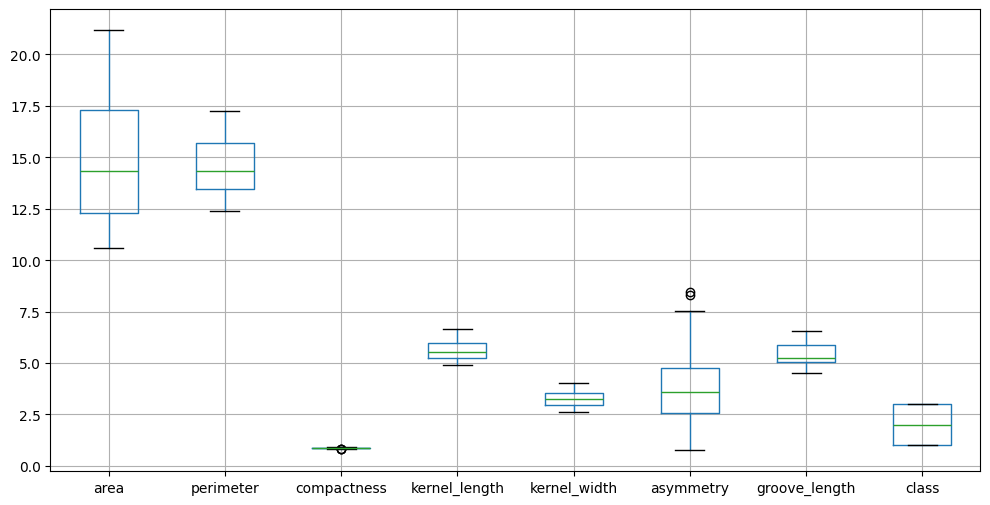

In [24]:
seeds_df.boxplot(figsize=(12,6))
plt.show()

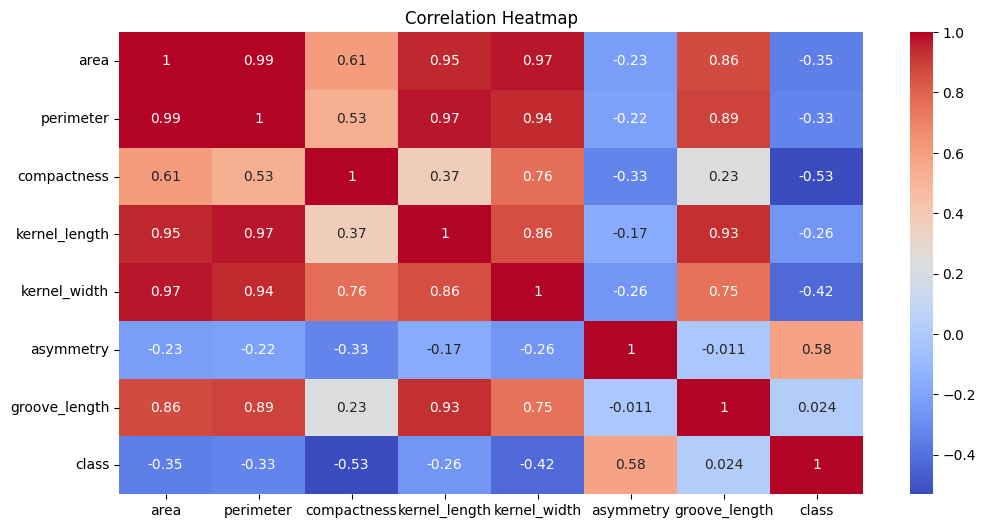

In [25]:
plt.figure(figsize=(12,6))
sns.heatmap(seeds_df.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.title('Correlation Heatmap')
plt.show()

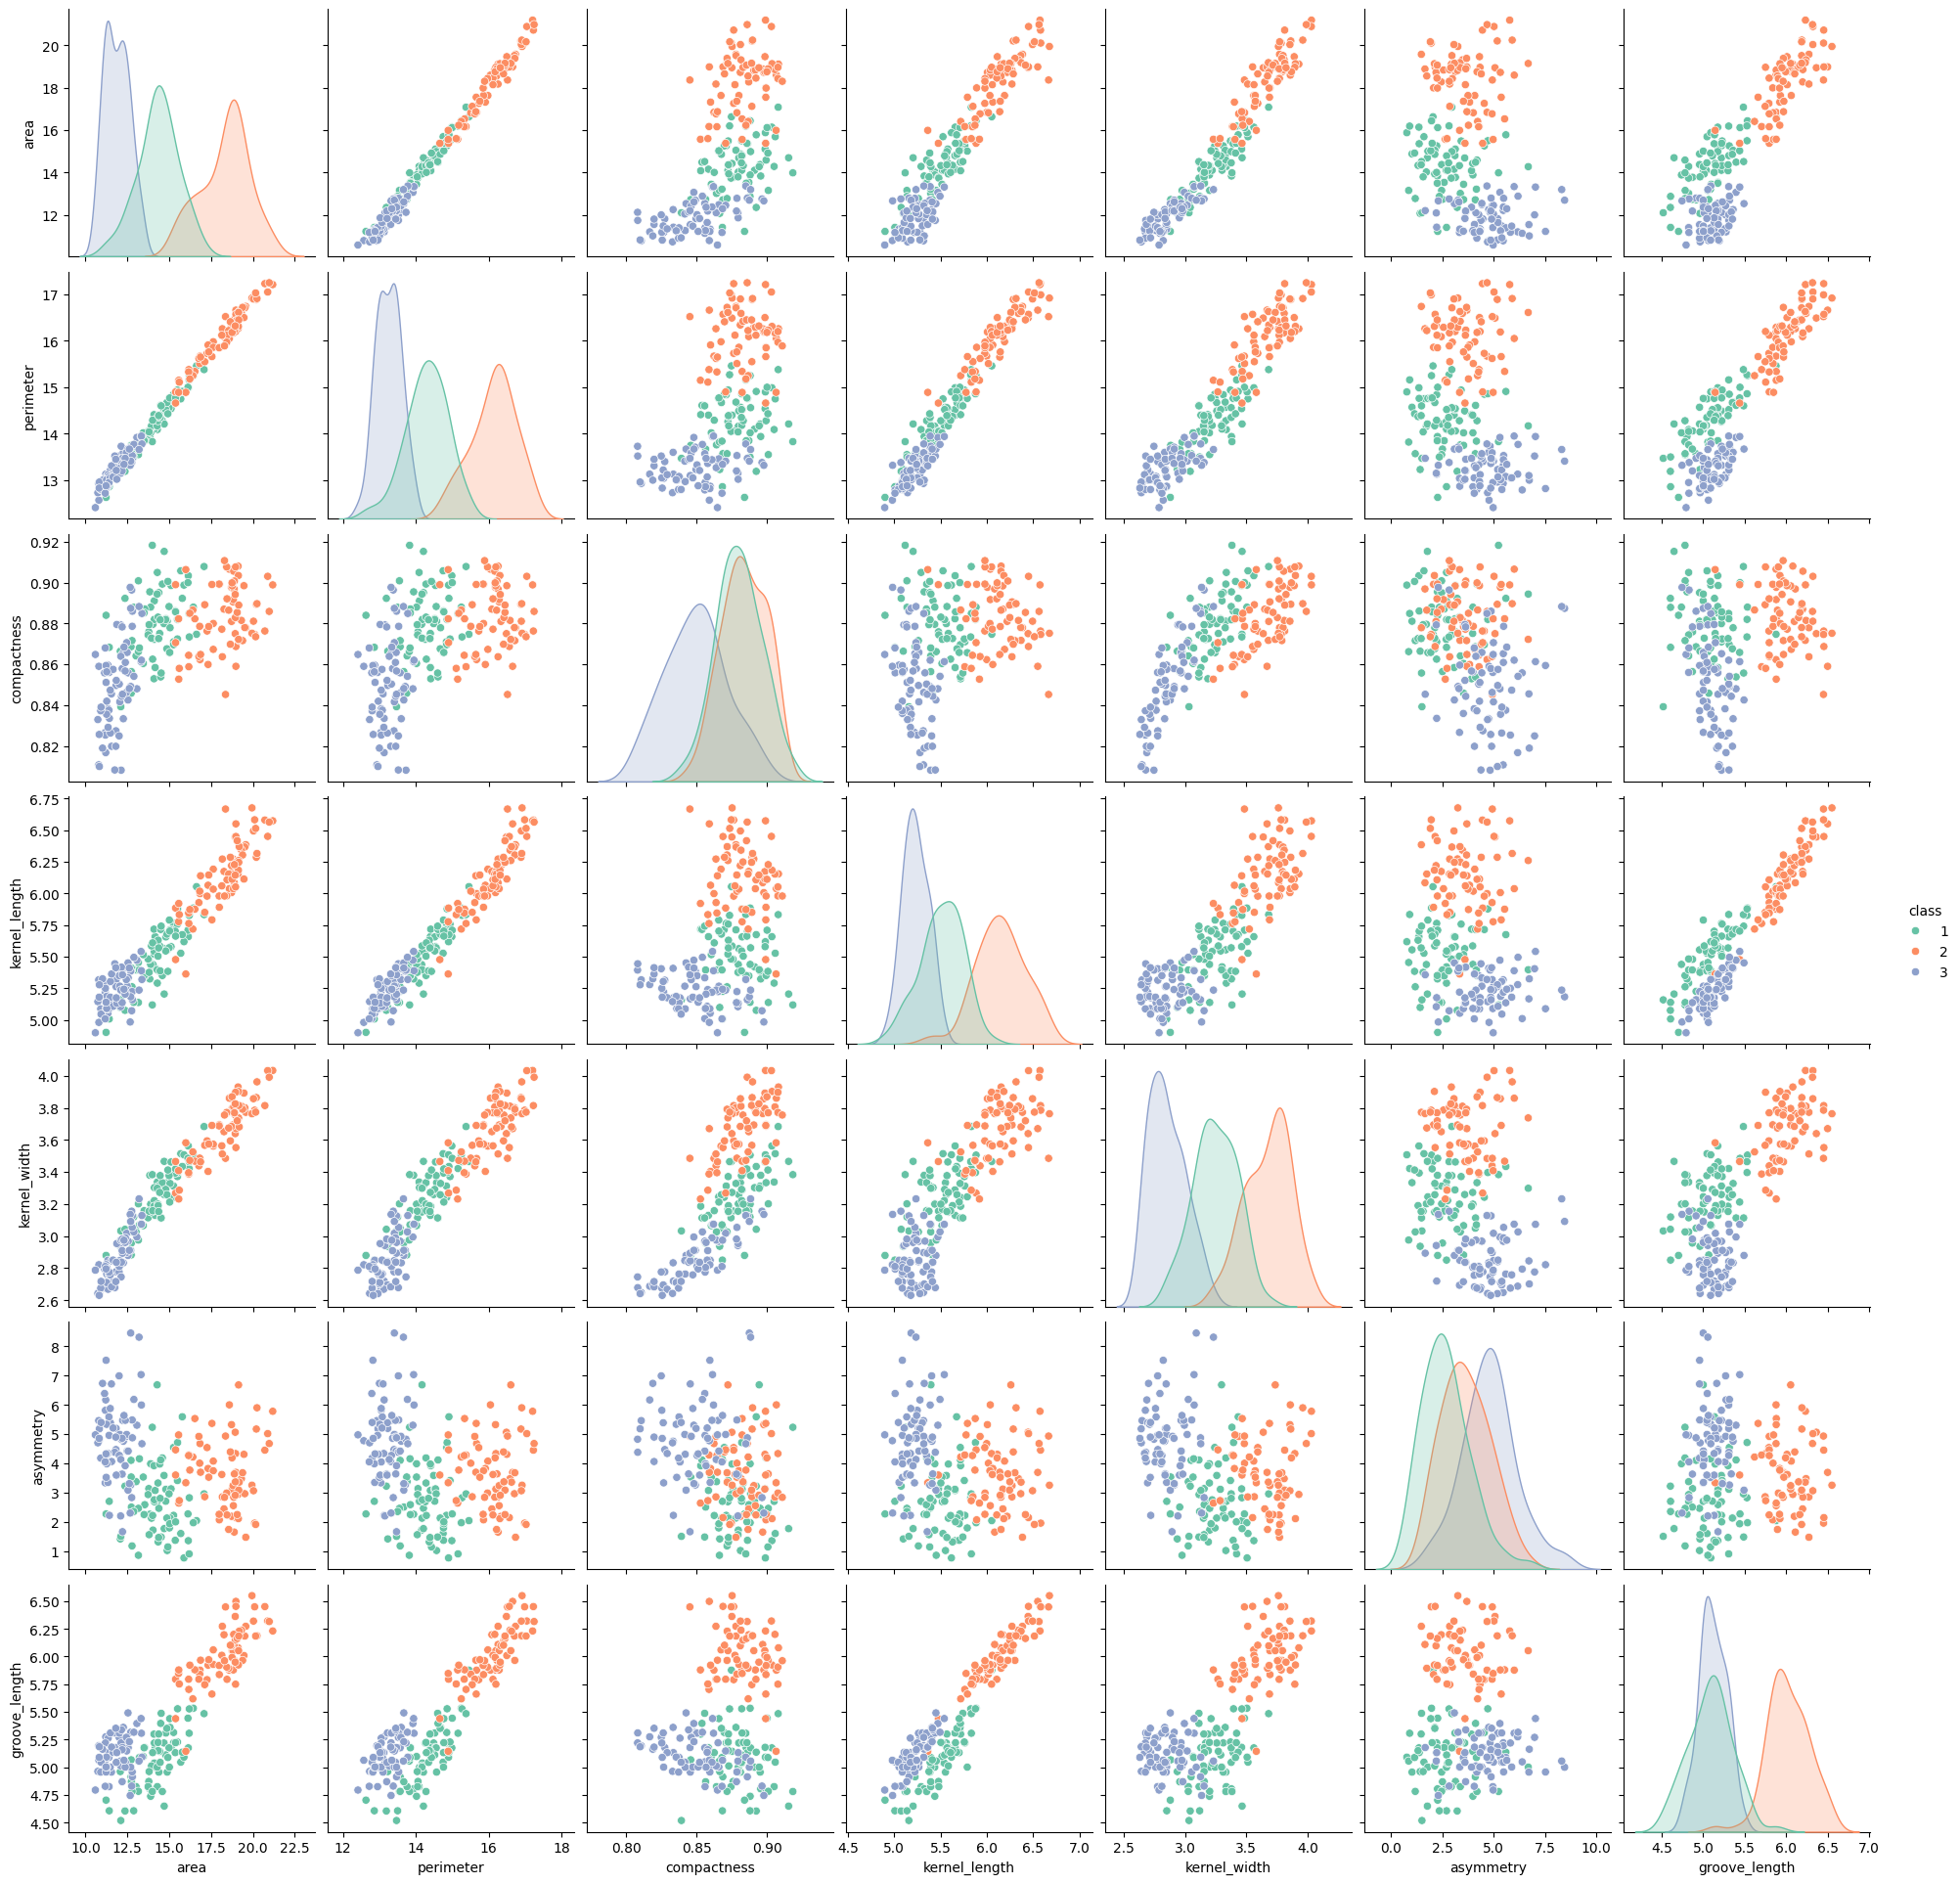

In [26]:
sns.pairplot(seeds_df, hue="class", palette="Set2", height=2.8)
plt.show()


In [29]:
X = seeds_df.drop("class", axis=1)
y = seeds_df["class"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

knn = KNeighborsClassifier(n_neighbors=5)

knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print("Accuracy:", accuracy_score(y_test, pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, pred))

Accuracy: 0.8809523809523809

Confusion Matrix:
[[ 9  0  2]
 [ 0 14  0]
 [ 3  0 14]]
